In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import seaborn as sns

from pathlib import Path
from MITRotor import IEA10MW
from wrf_io import postproc

In [2]:
rotor = IEA10MW()

nElements = 30
nSections = 160

In [3]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [4]:
wrfles_bem = []
wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/uniform_test/new_testing/U07_matching/U07_lite.npz')))

In [5]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/uniform_test/new_testing/U07_matching/input_sounding")

data = extract_columns(file_list)

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles_bem[0]['diameter']/2 + 378

In [6]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [7]:
def annulus_average(theta, X):

    dtheta = np.gradient(theta)
    weights = dtheta / np.sum(dtheta)
    X_azim = np.sum(X * weights, axis=1)

    return X_azim

def annulus_average_0(theta, X):

    dtheta = np.gradient(theta)
    weights = dtheta / np.sum(dtheta)
    X_azim = np.sum(X * weights, axis=0)

    return X_azim

def rotor_average(r, X):
    # Takes annulus average quantities and performs rotor average

    dr = np.gradient(r)
    area_elements = 2 * np.pi * r * dr  # differential area for annular rings
    integrand = X * area_elements

    A = np.pi * (1**2 - (2.4/99.5)**2)  # total area of annulus from R1 to R2

    X_rotor =  np.sum(integrand) / A

    return X_rotor

/tmp/ipykernel_3468069/1467822587.py:111: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=110, edgecolor='none',color=colors[count],alpha=0.5, zorder = count + 2)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


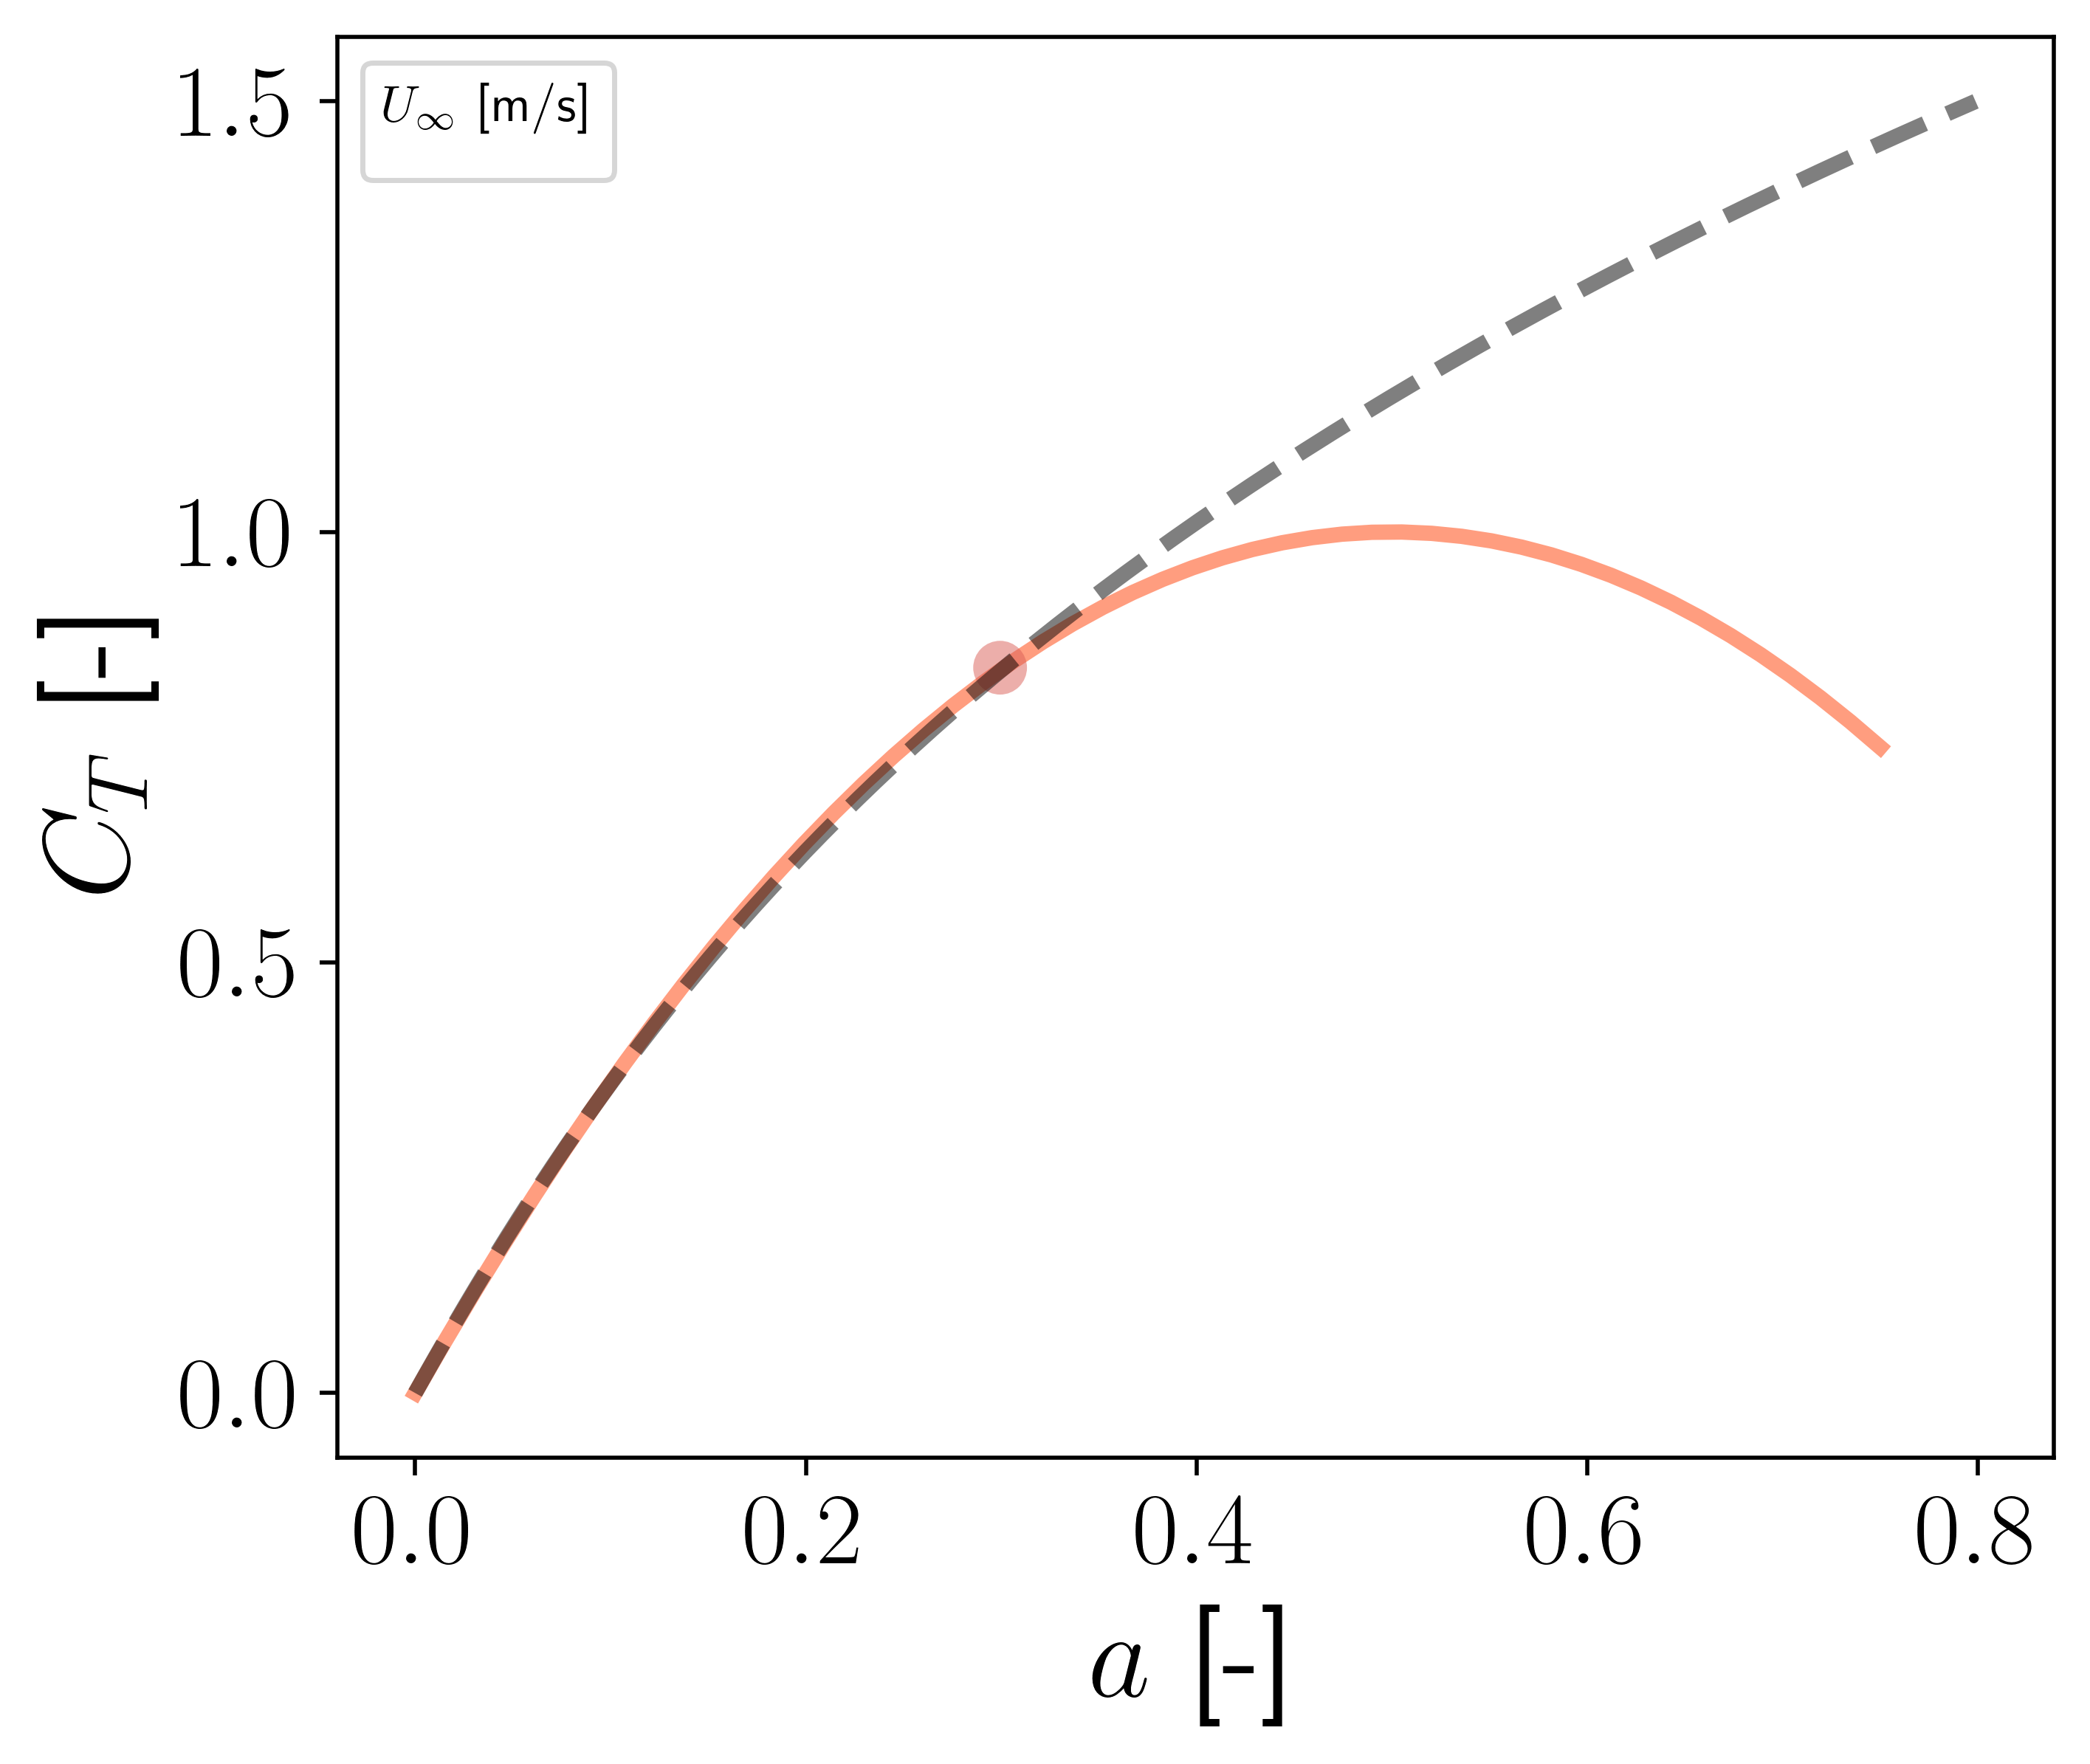

In [11]:
Nelm = 30
Nsct = 160

casenames = ['U07_matching']

ind_rotor = np.zeros_like(casenames, dtype=float)
ct_rotor  = np.zeros_like(casenames, dtype=float)

ind_loc = np.zeros((nElements, nSections, len(casenames)))
ct_loc  = np.zeros((nElements, nSections, len(casenames)))

colors = sns.color_palette("hls", 5)

fig, ax = plt.subplots(figsize=(6, 5))

for count,case in enumerate(casenames):

    R = wrfles_bem[count]['radius']

    # Extract background flow from sounding file
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # Compute hub height velocity for normalization
    U_hub = np.sqrt(u_func(398)**2 + v_func(398)**2)

    # u and v velocity functions for freestream flow
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Extract velocity components at the rotor disk
    u_rotor = np.mean(wrfles_bem[count]['v1'],axis=0)
    v_rotor = np.mean(wrfles_bem[count]['v'],axis=0)
    w_rotor = np.mean(wrfles_bem[count]['w'],axis=0)

    # Compute local axial induction
    ind = 1 - u_rotor / U_hub

    # Compute rotor average of axial induction
    ind_avg = rotor_average(wrfles_bem[count]['rOverR'], annulus_average(np.linspace(0, 2*np.pi, nSections), ind))

    # Compute new rotor disk velocities based on background flow and rotor-averaged axial induction
    u_avg = ((((1-ind_avg) * u_inf)**2 + v_inf**2)**(1/2) * np.cos(np.atan2(v_inf, u_inf))).T
    v_avg = ((((1-ind_avg) * u_inf)**2 + v_inf**2)**(1/2) * np.sin(np.atan2(v_inf, u_inf))).T

    # Nondimensional radial positions
    r = wrfles_bem[count]['rOverR']
    r_mat =  (np.ones_like(u_inf) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles_bem[count]['Nsct'])

    # Radial chord lengths
    chord = [4.649118,4.890711,5.132303,5.373896,5.615488,5.857080,5.959029,5.917359,5.658924,5.400488,5.142053,4.883618,4.625183,4.366748,4.108313,3.835882,3.555919,3.275956,3.037851,2.801943,2.566033,2.307137,2.047028,1.786918,1.526808,1.266698,1.006588,0.746478,0.486368,0.226259]

    chord =  (np.ones_like(u_inf) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma_r = 3 * chord / (2 * np.pi * r_mat * R)

    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles_bem[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = 0

    Vax, Vtn_NR, _ = postproc.rotGlobalToLocal(Nelm,Nsct,u_avg,v_avg,np.zeros_like(u_rotor))

    Vtn = omega * r_mat * R - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angleCompu
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma_r * (W/U_hub)**2 * Cax

    rho = 1.225

    L = 1/2 * rho * chord * (Cl * W**2)
    D = 1/2 * rho * chord * (Cd * W**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)

    ct_annular = annulus_average(np.linspace(0, 2*np.pi, nSections), ct)
    ind_annular = annulus_average(np.linspace(0, 2*np.pi, nSections), ind)

    ct_rotor[count]  = rotor_average(wrfles_bem[count]['rOverR'], ct_annular)

    ind_rotor[count] = rotor_average(wrfles_bem[count]['rOverR'], ind_annular)
    ax.scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=110, edgecolor='none',color=colors[count],alpha=0.5, zorder = count + 2)


a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,alpha = 0.5, zorder = 1)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,alpha=0.5,zorder=2)

ax.set_xlabel('$a$ [-]', fontsize=fontsize)
ax.set_ylabel('$C_T$ [-]', fontsize=fontsize)

plt.legend(title='$U_{\infty}$ [m/s]')

plt.show()

In [12]:
[ind_rotor[0], ct_rotor[0]]

[np.float64(0.2994519594437293), np.float64(0.8423220326478874)]

In [21]:
P/1000

np.float64(3478.766237346826)

In [16]:
np.mean(wrfles_bem[count]['omega'], axis=0) * 2 * np.pi / 60 * 99.5 / 7

array([10.63396192])

In [20]:
sigma_r[:,0]

array([0.55241568, 0.32186664, 0.23356577, 0.18690152, 0.15804291,
       0.13843163, 0.12139203, 0.10591681, 0.09033055, 0.07778802,
       0.06747697, 0.05885052, 0.05152702, 0.04523199, 0.039763  ,
       0.03484034, 0.03042427, 0.02649237, 0.02329007, 0.0204202 ,
       0.01782052, 0.01530216, 0.01299281, 0.01087398, 0.00892304,
       0.00712078, 0.00545085, 0.00389917, 0.00245363, 0.00110369])